In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Libraries
from nltk.corpus import stopwords
import spacy

# machine learning packages


In [20]:
df = pd.read_csv("../Data/cleaned_csv")

df.head()
# df.columns
df = df.drop(['Unnamed: 0.1' , 'Unnamed: 0'] , axis=1)

df.head()

df['sentiment'].value_counts()

sentiment
negative    23030
positive    22847
Name: count, dtype: int64

In [21]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

df['sentiment'].astype(int)

df.head()



,review,sentiment,text_length,cleaned_review
0,One of the other reviewers has mentioned that ...,1,1761,reviewer mention watch episode hook right exac...
1,A wonderful little production. <br /><br />The...,1,998,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,1,926,think wonderful way spend time hot summer week...
3,Basically there's a family where a little boy ...,0,748,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317,petter matteis love time money visually stunni...


In [25]:
# now Feature engineering step
from sklearn.feature_extraction.text import TfidfVectorizer


unique_words = set([i for i in df['cleaned_review']])

vectorizer = TfidfVectorizer( max_features = 5000, ngram_range = (1,2))

len(unique_words)

45873

In [26]:
X = vectorizer.fit_transform(df['cleaned_review'])

y = df['sentiment']

In [27]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y, test_size=0.2 , random_state=42)



In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train , y_train)

y_pred = model.predict(y_test)



In [31]:
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix, f1_score


print(accuracy_score(y_test , y_pred))
print(classification_report(y_test , y_pred))
print(confusion_matrix(y_test , y_pred))
print(f1_score(y_test , y_pred))

0.8851351351351351
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4596
           1       0.88      0.90      0.89      4580

    accuracy                           0.89      9176
   macro avg       0.89      0.89      0.89      9176
weighted avg       0.89      0.89      0.89      9176

[[4012  584]
 [ 470 4110]]
0.8863489324994609


In [ ]:
# ROC_CURVE

from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr , thresholds = roc_curve(y_test, y_prob)

ValueError: too many values to unpack (expected 2)

In [35]:
auc_score = roc_auc_score(y_test, y_prob)

print(auc_score)

0.9550768942805781


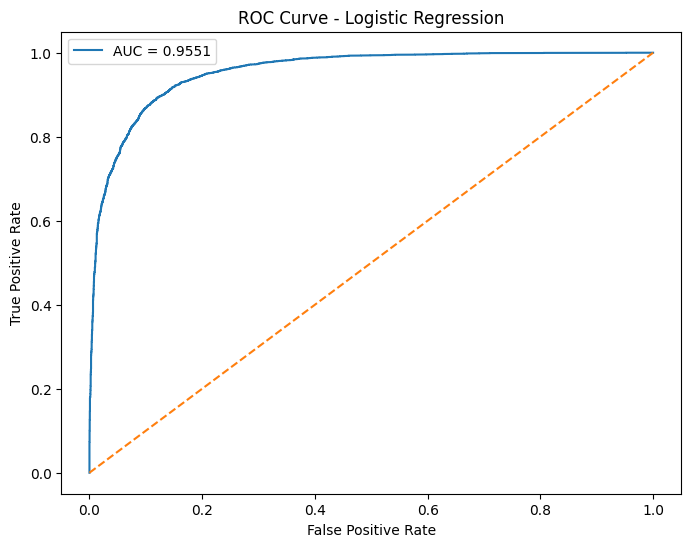

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

# random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

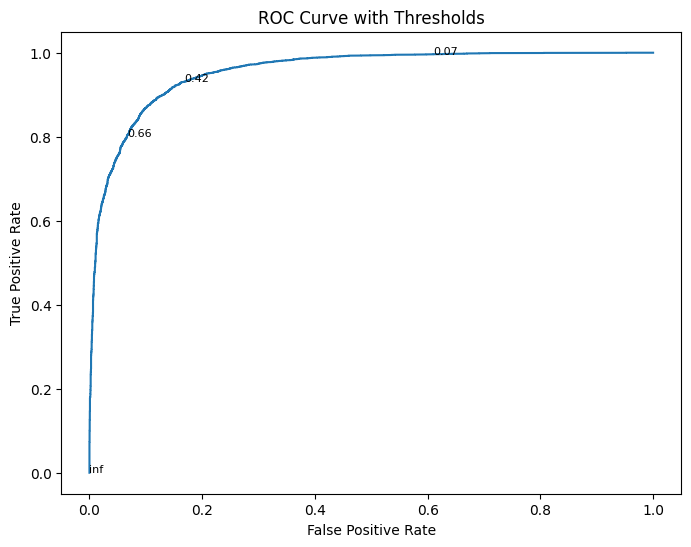

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

for i in range(0, len(thresholds), 500):

    plt.text(
        fpr[i],
        tpr[i],
        f"{thresholds[i]:.2f}",
        fontsize=8
    )

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve with Thresholds")

plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()


nb_prob = nb_model.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

In [41]:
# models scores
log_model = LogisticRegression()
nb_model = MultinomialNB()
svm_model = LinearSVC()

models = [log_model , nb_model , svm_model]
results = []

for model in models:
    model.fit(X_train , y_train)
    y_pred = model.predict(X_test)
    obj = {
        'Model': model.__class__.__name__,
        'Accuracy': accuracy_score(y_test , y_pred),
        'F1 Score': f1_score(y_test , y_pred),
    }

    results.append(obj)


In [44]:
scores = pd.DataFrame(results)
scores

,Model,Accuracy,F1 Score
0,LogisticRegression,0.885135,0.886349
1,MultinomialNB,0.859634,0.861326
2,LinearSVC,0.879250,0.880346


In [ ]:
feature_names = vectorizer.get_feature_names_out()

In [49]:
coefficients = log_model.coef_[0]

In [51]:
top_positive_indices = coefficients.argsort()[-20:]

In [52]:
top_positive_words = feature_names[top_positive_indices]

top_positive_scores = coefficients[top_positive_indices]

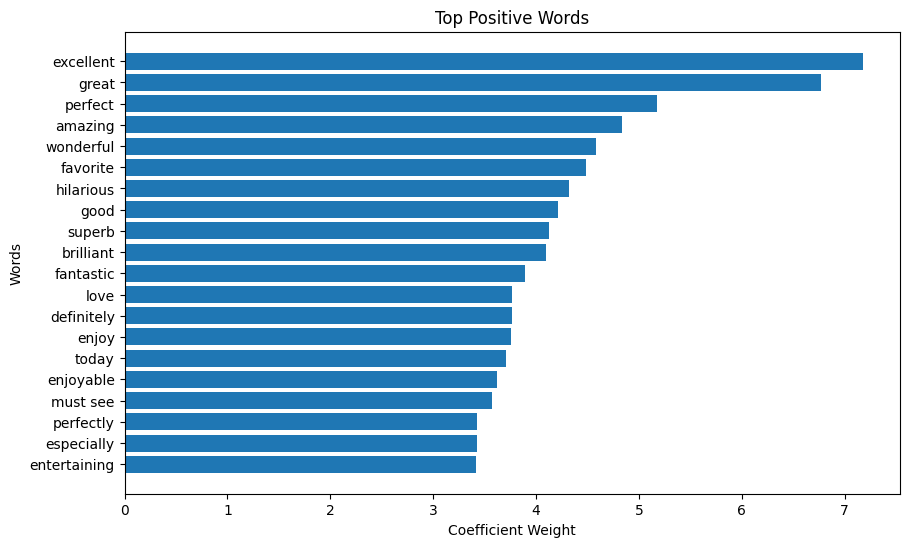

In [ ]:


plt.figure(figsize=(10,6))

plt.barh(
    top_positive_words,
    top_positive_scores
)

plt.title("Top Positive Words")

plt.xlabel("Coefficient Weight")
plt.ylabel("Words")

plt.show()

In [56]:
top_negative_indices = coefficients.argsort()[:20]

In [57]:
top_negative_words = feature_names[top_negative_indices]
top_negative_scores= coefficients[top_negative_indices]


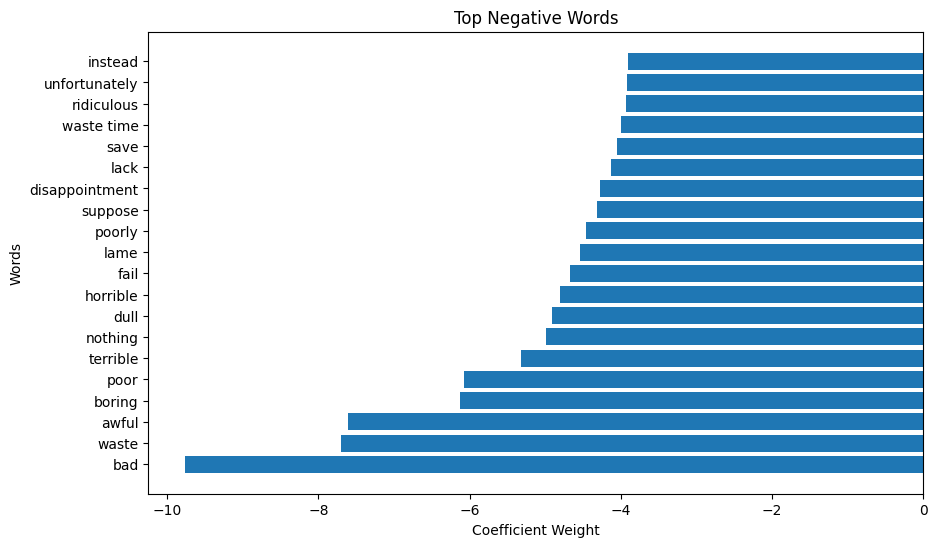

In [58]:
plt.figure(figsize=(10,6))

plt.barh(
    top_negative_words,
    top_negative_scores
)

plt.title("Top Negative Words")

plt.xlabel("Coefficient Weight")
plt.ylabel("Words")

plt.show()